# Task 3: Evaluation Metrics Analysis

> "In our lust for measurement, we frequently measure that which we can rather than that which we wish to measure...and forget that there is a difference." ~ George Udny Yule

## Metrics Implemented

1. **Progress-Based Score** - How much of the string was reduced (0 to 1)
2. **Valid Steps Ratio** - What % of attempted steps were valid (0 to 1)
3. **Composite Multi-Metric Score** - Weighted combination (0 to 1)

## Goals
- Analyze how different metrics score real LLM outputs
- Compare metrics across models and prompting techniques
- Test edge cases to validate metric robustness
- Determine which metric works best in which scenario


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
import sys
sys.path.insert(0, str(Path('..').resolve()))

from llm_evaluation.metrics_advanced import (
    evaluate_all_results, 
    analyze_edge_cases, 
    format_example,
    load_all_data,
    simulate_solution,
    calculate_progress_score,
    calculate_valid_steps_ratio,
    calculate_composite_score
)

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Color schemes
MODEL_COLORS = {
    'llama-3.3-70b-versatile': '#3498db',
    'meta-llama/llama-4-scout-17b-16e-instruct': '#e74c3c',
    'llama-3.1-8b-instant': '#2ecc71',
}

MODEL_NAMES = {
    'llama-3.3-70b-versatile': 'LLaMA 3.3 70B',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'LLaMA 4 Scout',
    'llama-3.1-8b-instant': 'LLaMA 3.1 8B',
}

PROMPT_NAMES = {
    'zero_shot': 'Zero-Shot',
    'few_shot': 'Few-Shot',
    'cot': 'CoT',
    'self_verify': 'Self-Verify',
    'role_classify': 'Role-Classify',
}

print("Setup complete!")


Setup complete!


In [3]:
# Evaluate all results
base_path = Path('..').resolve()
all_metrics = evaluate_all_results(base_path)
puzzles, solutions, metadata = load_all_data(base_path)

print(f"📊 Evaluated {len(all_metrics)} LLM outputs")

# Convert to DataFrame for analysis
df = pd.DataFrame([{
    'problem_id': m.problem_id,
    'model': MODEL_NAMES.get(m.model, m.model),
    'prompt_type': PROMPT_NAMES.get(m.prompt_type, m.prompt_type),
    'difficulty': m.difficulty,
    'generator': m.generator,
    'is_correct': m.is_correct,
    'binary_accuracy': 1.0 if m.is_correct else 0.0,
    'progress_score': m.progress_score,
    'valid_steps_ratio': m.valid_steps_ratio,
    'composite_score': m.composite_score,
    'initial_length': m.initial_length,
    'final_length': m.final_length,
    'valid_steps': m.valid_steps,
    'total_steps': m.total_steps,
    'solution_length': len(m.parsed_solution),
    'optimal_length': len(m.ground_truth),
} for m in all_metrics])

print(f"\n📋 DataFrame shape: {df.shape}")
df.head()


📊 Evaluated 480 LLM outputs

📋 DataFrame shape: (480, 16)


,problem_id,model,prompt_type,difficulty,generator,is_correct,binary_accuracy,progress_score,valid_steps_ratio,composite_score,initial_length,final_length,valid_steps,total_steps,solution_length,optimal_length
0,000,LLaMA 3.1 8B,Role-Classify,medium,backward_5,True,1.0,1.000000,1.000000,1.000000,16,0,5,5,5,5
1,001,LLaMA 3.1 8B,Role-Classify,medium,backward_5,False,0.0,0.166667,0.333333,0.091667,18,15,1,3,3,5
2,002,LLaMA 3.1 8B,Role-Classify,medium,backward_5,False,0.0,0.636364,0.750000,0.271591,11,4,3,4,4,5
3,005,LLaMA 3.1 8B,Role-Classify,medium,backward_5,True,1.0,1.000000,0.086207,0.771552,16,0,5,58,58,5
4,010,LLaMA 3.1 8B,Role-Classify,hard,backward_7,False,0.0,0.937500,0.093333,0.248375,16,1,7,75,75,7


## 2. Metrics Overview: Distributions and Statistics


In [4]:
# Summary statistics for all metrics
print("="*80)
print("METRICS SUMMARY STATISTICS")
print("="*80)

metrics_to_compare = ['binary_accuracy', 'progress_score', 'valid_steps_ratio', 'composite_score']
stats_df = df[metrics_to_compare].describe().round(3)
print(stats_df)

print("\n" + "="*80)
print("CORRELATION BETWEEN METRICS")
print("="*80)
corr = df[metrics_to_compare].corr().round(3)
print(corr)


METRICS SUMMARY STATISTICS
       binary_accuracy  progress_score  valid_steps_ratio  composite_score
count          480.000         480.000            480.000          480.000
mean             0.508           0.712              0.710            0.576
std              0.500           0.390              0.320            0.380
min              0.000           0.000              0.000            0.000
25%              0.000           0.510              0.500            0.237
50%              1.000           1.000              0.778            0.764
75%              1.000           1.000              1.000            1.000
max              1.000           1.000              1.000            1.000

CORRELATION BETWEEN METRICS
                   binary_accuracy  progress_score  valid_steps_ratio  \
binary_accuracy              1.000           0.753              0.111   
progress_score               0.753           1.000              0.286   
valid_steps_ratio            0.111           0.286

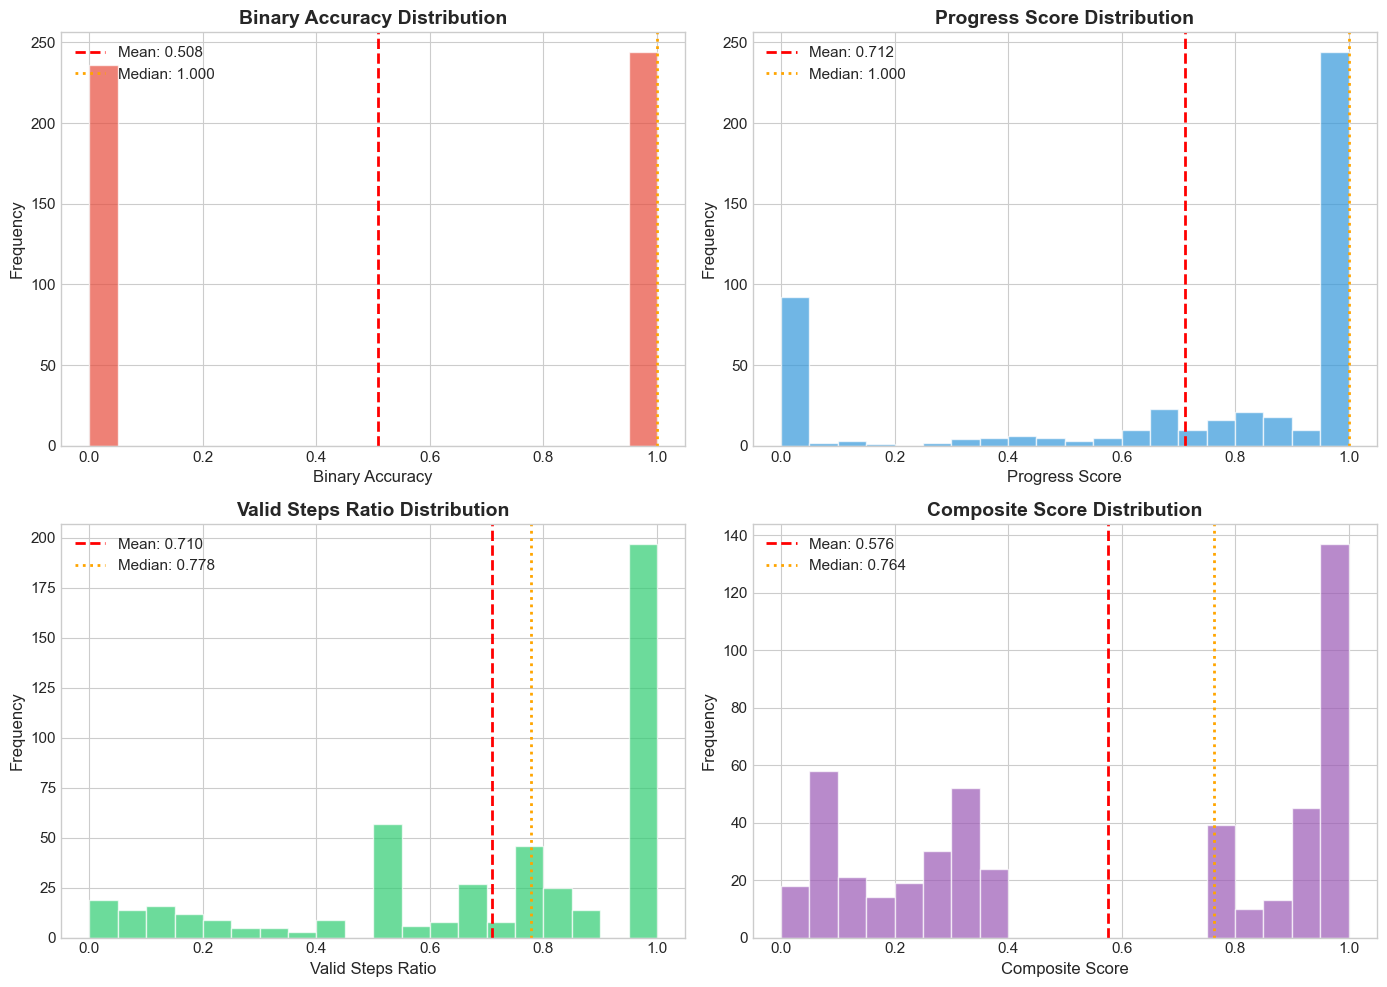

📊 Key Observations:
  • Binary Accuracy is highly bimodal (0 or 1)
  • Progress Score shows a wider distribution with partial credit
  • Valid Steps Ratio is often high even for incorrect answers
  • Composite Score smooths out the extremes


In [5]:
# Visualize metric distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_info = [
    ('binary_accuracy', 'Binary Accuracy', '#e74c3c'),
    ('progress_score', 'Progress Score', '#3498db'),
    ('valid_steps_ratio', 'Valid Steps Ratio', '#2ecc71'),
    ('composite_score', 'Composite Score', '#9b59b6'),
]

for ax, (metric, title, color) in zip(axes.flatten(), metric_info):
    ax.hist(df[metric], bins=20, color=color, edgecolor='white', alpha=0.7)
    ax.axvline(df[metric].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[metric].mean():.3f}')
    ax.axvline(df[metric].median(), color='orange', linestyle=':', linewidth=2, label=f'Median: {df[metric].median():.3f}')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title} Distribution', fontweight='bold')
    ax.legend()
    ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('../results/metrics_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("📊 Key Observations:")
print(f"  • Binary Accuracy is highly bimodal (0 or 1)")
print(f"  • Progress Score shows a wider distribution with partial credit")
print(f"  • Valid Steps Ratio is often high even for incorrect answers")
print(f"  • Composite Score smooths out the extremes")


## 3. Comparing Metrics Across Models


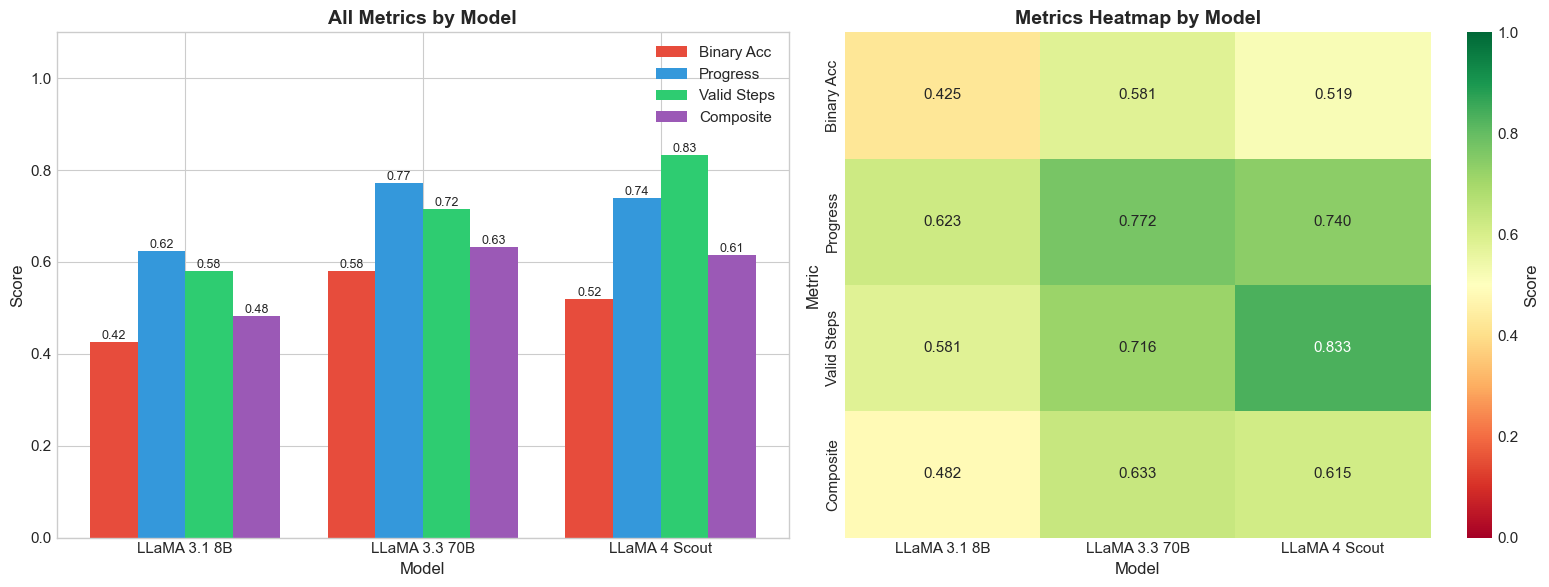


📊 Model Comparison Table:
               binary_accuracy  progress_score  valid_steps_ratio  composite_score
model                                                                             
LLaMA 3.1 8B             0.425           0.623              0.581            0.482
LLaMA 3.3 70B            0.581           0.772              0.716            0.633
LLaMA 4 Scout            0.519           0.740              0.833            0.615


In [6]:
# Compare metrics across models
model_metrics = df.groupby('model')[metrics_to_compare].mean().round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grouped bar chart
ax1 = axes[0]
x = np.arange(len(model_metrics.index))
width = 0.2
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
labels = ['Binary Acc', 'Progress', 'Valid Steps', 'Composite']

for i, (metric, label) in enumerate(zip(metrics_to_compare, labels)):
    bars = ax1.bar(x + i*width, model_metrics[metric], width, label=label, color=colors[i])
    for bar, val in zip(bars, model_metrics[metric]):
        ax1.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('All Metrics by Model', fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(model_metrics.index, rotation=0)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1.1)

# 2. Radar/Spider chart alternative - Heatmap
ax2 = axes[1]
model_metrics_T = model_metrics.T
model_metrics_T.index = labels
sns.heatmap(model_metrics_T, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, ax=ax2, cbar_kws={'label': 'Score'})
ax2.set_title('Metrics Heatmap by Model', fontweight='bold')
ax2.set_ylabel('Metric')
ax2.set_xlabel('Model')

plt.tight_layout()
plt.savefig('../results/metrics_by_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Model Comparison Table:")
print(model_metrics.to_string())


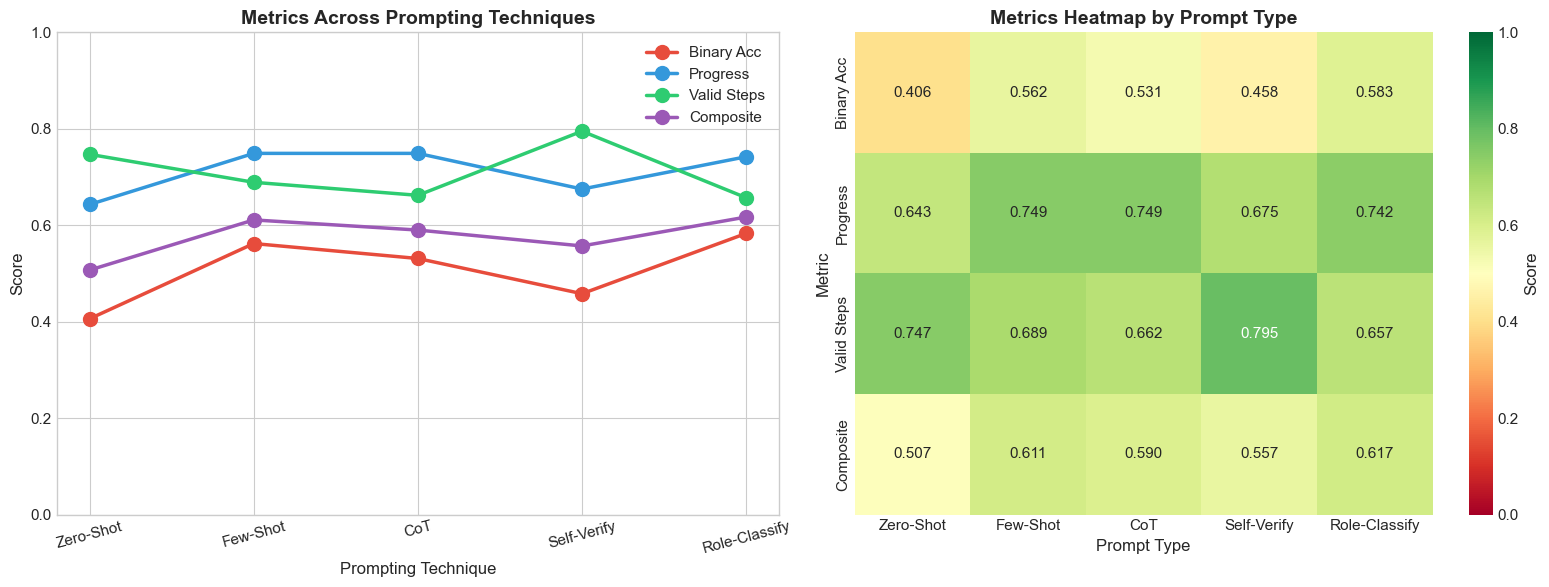


📊 Prompt Type Comparison Table:
               binary_accuracy  progress_score  valid_steps_ratio  composite_score
prompt_type                                                                       
Zero-Shot                0.406           0.643              0.747            0.507
Few-Shot                 0.562           0.749              0.689            0.611
CoT                      0.531           0.749              0.662            0.590
Self-Verify              0.458           0.675              0.795            0.557
Role-Classify            0.583           0.742              0.657            0.617


In [7]:
# Compare metrics across prompt types
prompt_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']
prompt_metrics = df.groupby('prompt_type')[metrics_to_compare].mean().reindex(prompt_order).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Line plot showing metric trends across prompts
ax1 = axes[0]
for metric, color, label in zip(metrics_to_compare, colors, labels):
    ax1.plot(prompt_metrics.index, prompt_metrics[metric], marker='o', markersize=10,
            linewidth=2.5, color=color, label=label)

ax1.set_xlabel('Prompting Technique')
ax1.set_ylabel('Score')
ax1.set_title('Metrics Across Prompting Techniques', fontweight='bold')
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='x', rotation=15)

# 2. Heatmap
ax2 = axes[1]
prompt_metrics_T = prompt_metrics.T
prompt_metrics_T.index = labels
sns.heatmap(prompt_metrics_T, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax2, cbar_kws={'label': 'Score'})
ax2.set_title('Metrics Heatmap by Prompt Type', fontweight='bold')
ax2.set_ylabel('Metric')
ax2.set_xlabel('Prompt Type')

plt.tight_layout()
plt.savefig('../results/metrics_by_prompt.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Prompt Type Comparison Table:")
print(prompt_metrics.to_string())


## 5. Edge Case Analysis: How Metrics Behave in Different Scenarios


In [8]:
# Identify edge cases
edge_cases = analyze_edge_cases(base_path)

print("="*80)
print("EDGE CASE CATEGORIES")
print("="*80)

for category, examples in edge_cases.items():
    print(f"\n{category}: {len(examples)} examples")

# Create edge case summary table
edge_summary = []
for category, examples in edge_cases.items():
    if examples:
        avg_progress = np.mean([e.progress_score for e in examples])
        avg_valid = np.mean([e.valid_steps_ratio for e in examples])
        avg_composite = np.mean([e.composite_score for e in examples])
        edge_summary.append({
            'Category': category,
            'Count': len(examples),
            'Avg Progress': avg_progress,
            'Avg Valid Steps': avg_valid,
            'Avg Composite': avg_composite,
        })

edge_df = pd.DataFrame(edge_summary)
print("\n" + "="*80)
print("EDGE CASE METRICS SUMMARY")
print("="*80)
print(edge_df.to_string(index=False))


EDGE CASE CATEGORIES

correct_optimal: 125 examples

correct_longer: 119 examples

almost_there: 75 examples

good_progress: 61 examples

minimal_progress: 100 examples

all_valid_wrong: 72 examples

mostly_invalid: 37 examples

parsing_failure: 0 examples

zero_steps: 3 examples

EDGE CASE METRICS SUMMARY
        Category  Count  Avg Progress  Avg Valid Steps  Avg Composite
 correct_optimal    125      1.000000         1.000000       1.000000
  correct_longer    119      1.000000         0.477107       0.869277
    almost_there     75      0.824863         0.805013       0.326968
   good_progress     61      0.565082         0.784616       0.258963
minimal_progress    100      0.012090         0.508288       0.079266
 all_valid_wrong     72      0.648883         1.000000       0.312221
  mostly_invalid     37      0.365932         0.185029       0.119237
      zero_steps      3      0.000000         0.000000       0.000000


In [11]:
# Show detailed examples from key edge cases
key_categories = ['correct_optimal', 'almost_there', 'all_valid_wrong', 'minimal_progress']

for category in key_categories:
    examples = edge_cases.get(category, [])
    if examples:
        print("="*80)
        print(f"EXAMPLE: {category.upper().replace('_', ' ')}")
        print("="*80)
        
        # Pick a representative example
        ex = examples[0]
        
        # Get puzzle data
        puzzle = puzzles.get(ex.problem_id, {})
        
        print(f"\nProblem ID: {ex.problem_id}")
        print(f"Model: {ex.model}")
        print(f"Prompt: {ex.prompt_type}")
        print(f"Difficulty: {ex.difficulty}")
        print(f"Generator: {ex.generator}")
        print(f"\nInitial String: \"{puzzle.get('initial_string', 'N/A')}\" (length: {ex.initial_length})")
        print(f"Final String after LLM solution: length {ex.final_length}")
        print(f"\nGround Truth: {ex.ground_truth}")
        print(f"LLM Solution: {ex.parsed_solution}")
        print(f"\n--- METRICS ---")
        print(f"  Binary Accuracy:    {'✓ 1.0' if ex.is_correct else '✗ 0.0'}")
        print(f"  Progress Score:     {ex.progress_score:.3f}")
        print(f"  Valid Steps Ratio:  {ex.valid_steps_ratio:.3f} ({ex.valid_steps}/{ex.total_steps} valid)")
        print(f"  Composite Score:    {ex.composite_score:.3f}")
        print()


EXAMPLE: CORRECT OPTIMAL

Problem ID: 000
Model: llama-3.1-8b-instant
Prompt: role_classify
Difficulty: medium
Generator: backward_5

Initial String: "CEAEEBEDDABCACBE" (length: 16)
Final String after LLM solution: length 0

Ground Truth: [0, 5, 1, 2, 6]
LLM Solution: [0, 1, 2, 5, 6]

--- METRICS ---
  Binary Accuracy:    ✓ 1.0
  Progress Score:     1.000
  Valid Steps Ratio:  1.000 (5/5 valid)
  Composite Score:    1.000

EXAMPLE: ALMOST THERE

Problem ID: 010
Model: llama-3.1-8b-instant
Prompt: role_classify
Difficulty: hard
Generator: backward_7

Initial String: "BDAEADEBCDEDBBBD" (length: 16)
Final String after LLM solution: length 1

Ground Truth: [5, 3, 1, 0, 4, 6, 2]
LLM Solution: [0, 1, 2, 3, 4, 5, 6, 7, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 2, 2, 4, 4, 5, 5, 7, 7, 8, 8, 2, 2, 3, 3, 6, 6, 7, 7, 4, 4, 5, 5, 2, 2, 0, 0, 1, 1, 3, 3, 5, 5, 6, 6, 7, 7, 8, 8, 2, 2, 4, 4, 0, 0, 1, 1, 2, 2]

--- METRICS ---
  Binary Accuracy:    ✗ 0.0
  Progress Score:     0.938
  Va

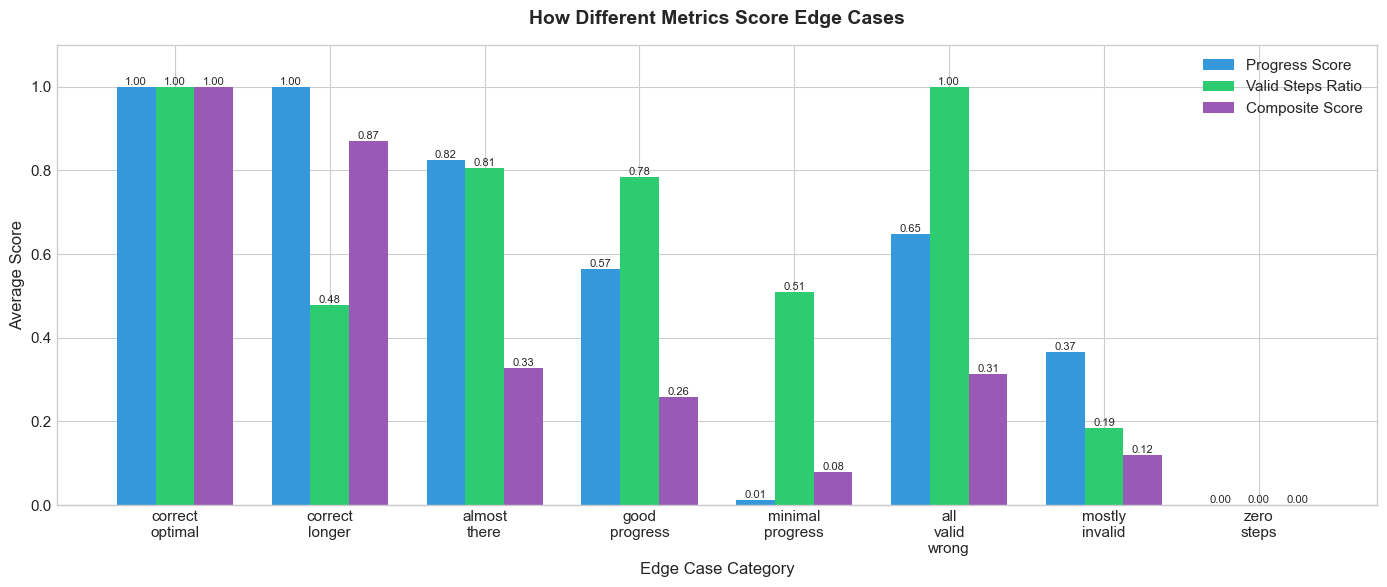

In [12]:
# Visualize edge case metrics
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for grouped bar chart
categories = [row['Category'] for row in edge_summary if row['Count'] > 0]
progress_vals = [row['Avg Progress'] for row in edge_summary if row['Count'] > 0]
valid_vals = [row['Avg Valid Steps'] for row in edge_summary if row['Count'] > 0]
composite_vals = [row['Avg Composite'] for row in edge_summary if row['Count'] > 0]

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, progress_vals, width, label='Progress Score', color='#3498db')
bars2 = ax.bar(x, valid_vals, width, label='Valid Steps Ratio', color='#2ecc71')
bars3 = ax.bar(x + width, composite_vals, width, label='Composite Score', color='#9b59b6')

ax.set_xlabel('Edge Case Category')
ax.set_ylabel('Average Score')
ax.set_title('How Different Metrics Score Edge Cases', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in categories], rotation=0)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../results/metrics_edge_cases.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 6. Metric Relationships: Scatter Plot Analysis


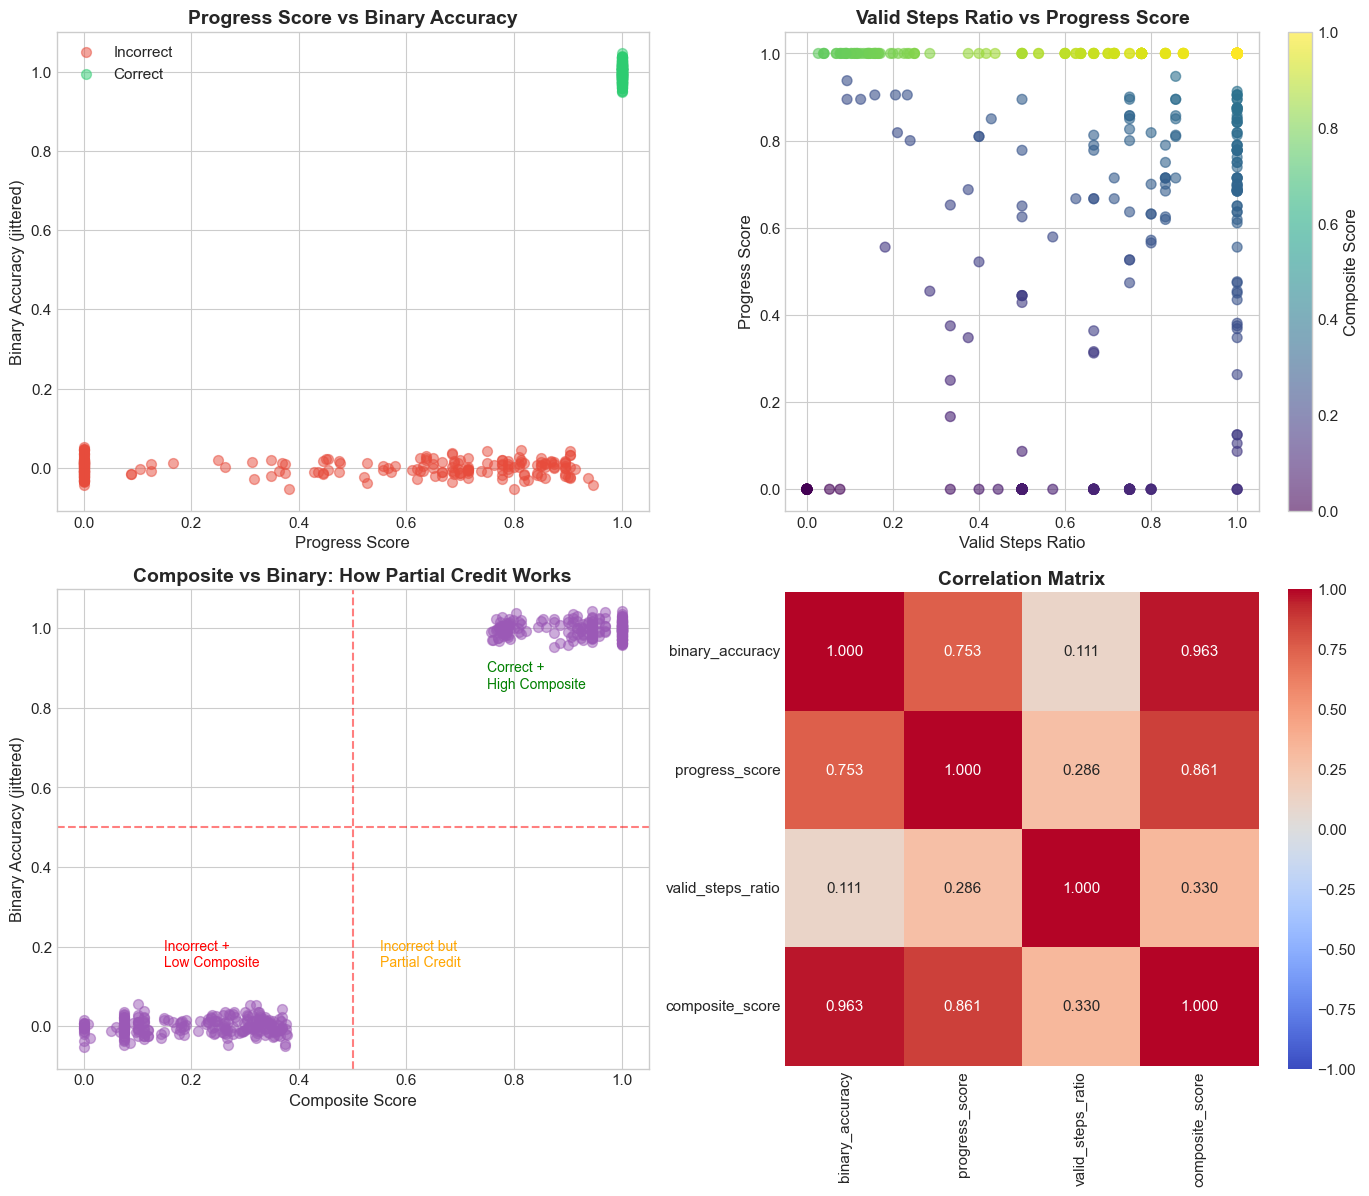

In [10]:
# Scatter plot matrix showing relationships between metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Add jitter for binary accuracy to see overlapping points
df_jittered = df.copy()
df_jittered['binary_jittered'] = df['binary_accuracy'] + np.random.normal(0, 0.02, len(df))

# 1. Progress vs Binary (with color by correctness)
ax1 = axes[0, 0]
correct = df[df['is_correct'] == True]
incorrect = df[df['is_correct'] == False]
ax1.scatter(incorrect['progress_score'], incorrect['binary_accuracy'] + np.random.normal(0, 0.02, len(incorrect)), 
           alpha=0.5, c='#e74c3c', label='Incorrect', s=50)
ax1.scatter(correct['progress_score'], correct['binary_accuracy'] + np.random.normal(0, 0.02, len(correct)), 
           alpha=0.5, c='#2ecc71', label='Correct', s=50)
ax1.set_xlabel('Progress Score')
ax1.set_ylabel('Binary Accuracy (jittered)')
ax1.set_title('Progress Score vs Binary Accuracy', fontweight='bold')
ax1.legend()

# 2. Valid Steps vs Progress
ax2 = axes[0, 1]
scatter = ax2.scatter(df['valid_steps_ratio'], df['progress_score'], 
                     c=df['composite_score'], cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, ax=ax2, label='Composite Score')
ax2.set_xlabel('Valid Steps Ratio')
ax2.set_ylabel('Progress Score')
ax2.set_title('Valid Steps Ratio vs Progress Score', fontweight='bold')

# 3. Composite vs Binary
ax3 = axes[1, 0]
ax3.scatter(df['composite_score'], df_jittered['binary_jittered'], 
           alpha=0.5, c='#9b59b6', s=50)
ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Composite Score')
ax3.set_ylabel('Binary Accuracy (jittered)')
ax3.set_title('Composite vs Binary: How Partial Credit Works', fontweight='bold')

# Add annotations for quadrants
ax3.annotate('Correct +\nHigh Composite', xy=(0.75, 0.85), fontsize=10, color='green')
ax3.annotate('Incorrect +\nLow Composite', xy=(0.15, 0.15), fontsize=10, color='red')
ax3.annotate('Incorrect but\nPartial Credit', xy=(0.55, 0.15), fontsize=10, color='orange')

# 4. Correlation heatmap
ax4 = axes[1, 1]
corr = df[metrics_to_compare].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
           vmin=-1, vmax=1, ax=ax4, square=True)
ax4.set_title('Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/metrics_relationships.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 7. Metric Comparison: Which Works When?


In [13]:
# Create a comprehensive metric comparison table
print("="*100)
print("METRIC COMPARISON: STRENGTHS AND WEAKNESSES")
print("="*100)

comparison_table = """
┌─────────────────────┬──────────────────────────────────────────────────────────────────────────────┐
│ METRIC              │ ANALYSIS                                                                      │
├─────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ BINARY ACCURACY     │ ✓ Clear, interpretable (0 or 1)                                              │
│                     │ ✓ Exact measure of task completion                                           │
│                     │ ✗ No partial credit - harsh on near-misses                                   │
│                     │ ✗ Cannot differentiate between quality of failures                          │
│                     │ → BEST FOR: Final task completion rate, simple comparisons                  │
├─────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ PROGRESS SCORE      │ ✓ Captures "how close" the model got                                         │
│                     │ ✓ Gives partial credit for partial success                                   │
│                     │ ✓ Smooth distribution (not bimodal)                                          │
│                     │ ✗ May reward random deletions that happen to reduce string                  │
│                     │ ✗ Doesn't verify if steps were valid                                         │
│                     │ → BEST FOR: Comparing quality of failed attempts, training feedback         │
├─────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ VALID STEPS RATIO   │ ✓ Measures understanding of rule application                                 │
│                     │ ✓ Identifies "knows the rules but wrong direction"                          │
│                     │ ✗ High validity doesn't mean progress toward goal                            │
│                     │ ✗ Can be misleading (100% valid but 0% progress)                            │
│                     │ → BEST FOR: Diagnosing if model understands syntax vs semantics             │
├─────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ COMPOSITE SCORE     │ ✓ Balanced view of multiple aspects                                          │
│                     │ ✓ Smooth gradients for optimization                                          │
│                     │ ✓ Captures both correctness and quality                                      │
│                     │ ✗ Weights are arbitrary (need tuning)                                        │
│                     │ ✗ Less interpretable than single metrics                                     │
│                     │ → BEST FOR: Overall model ranking, hyperparameter tuning                    │
└─────────────────────┴──────────────────────────────────────────────────────────────────────────────┘
"""
print(comparison_table)

# Quantitative comparison: Which metric best discriminates between models?
print("\n" + "="*100)
print("DISCRIMINATIVE POWER: Standard Deviation Across Models")
print("="*100)

for metric in metrics_to_compare:
    model_means = df.groupby('model')[metric].mean()
    std_across_models = model_means.std()
    range_across_models = model_means.max() - model_means.min()
    print(f"  {metric:20s}: σ={std_across_models:.4f}, range={range_across_models:.4f}")

print("\n→ Higher variance = better discrimination between models")


METRIC COMPARISON: STRENGTHS AND WEAKNESSES

┌─────────────────────┬──────────────────────────────────────────────────────────────────────────────┐
│ METRIC              │ ANALYSIS                                                                      │
├─────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ BINARY ACCURACY     │ ✓ Clear, interpretable (0 or 1)                                              │
│                     │ ✓ Exact measure of task completion                                           │
│                     │ ✗ No partial credit - harsh on near-misses                                   │
│                     │ ✗ Cannot differentiate between quality of failures                          │
│                     │ → BEST FOR: Final task completion rate, simple comparisons                  │
├─────────────────────┼──────────────────────────────────────────────────────────────────────────────┤
│ PROGRESS SCORE      │ ✓ Cap

## 8. Scenario-Specific Recommendations


In [14]:
# Scenario-specific analysis
print("="*100)
print("WHICH METRIC TO USE IN WHICH SCENARIO?")
print("="*100)

scenarios = [
    ("Scenario 1: Comparing Models for Deployment",
     "Use: Binary Accuracy + Composite Score",
     "Binary tells you task completion rate; Composite helps break ties"),
    
    ("Scenario 2: Debugging Why a Model Fails", 
     "Use: Valid Steps Ratio + Progress Score",
     "High Valid + Low Progress = understands syntax but not semantics"),
    
    ("Scenario 3: Training/Fine-tuning Feedback",
     "Use: Composite Score",
     "Smooth gradients for optimization, rewards partial improvements"),
    
    ("Scenario 4: Quick Benchmark Comparison",
     "Use: Binary Accuracy",
     "Simple, interpretable, widely understood"),
    
    ("Scenario 5: Analyzing Reasoning Quality",
     "Use: Progress Score + examine actual solutions",
     "Shows how close the model got, reveals reasoning patterns"),
]

for scenario, metric, reason in scenarios:
    print(f"\n{'─'*80}")
    print(f"📌 {scenario}")
    print(f"   → {metric}")
    print(f"   Reason: {reason}")


WHICH METRIC TO USE IN WHICH SCENARIO?

────────────────────────────────────────────────────────────────────────────────
📌 Scenario 1: Comparing Models for Deployment
   → Use: Binary Accuracy + Composite Score
   Reason: Binary tells you task completion rate; Composite helps break ties

────────────────────────────────────────────────────────────────────────────────
📌 Scenario 2: Debugging Why a Model Fails
   → Use: Valid Steps Ratio + Progress Score
   Reason: High Valid + Low Progress = understands syntax but not semantics

────────────────────────────────────────────────────────────────────────────────
📌 Scenario 3: Training/Fine-tuning Feedback
   → Use: Composite Score
   Reason: Smooth gradients for optimization, rewards partial improvements

────────────────────────────────────────────────────────────────────────────────
📌 Scenario 4: Quick Benchmark Comparison
   → Use: Binary Accuracy
   Reason: Simple, interpretable, widely understood

──────────────────────────────────────

## 9. Final Conclusions and Recommendations


In [15]:
print("="*100)
print("FINAL CONCLUSIONS")
print("="*100)

# Calculate final statistics
total_evals = len(df)
correct_count = df['is_correct'].sum()
binary_mean = df['binary_accuracy'].mean()
progress_mean = df['progress_score'].mean()
valid_mean = df['valid_steps_ratio'].mean()
composite_mean = df['composite_score'].mean()

print(f"""
📊 EVALUATION SUMMARY
   Total Evaluations: {total_evals}
   Correct Solutions: {correct_count} ({binary_mean*100:.1f}%)
   
📈 AVERAGE SCORES ACROSS ALL EVALUATIONS
   Binary Accuracy:    {binary_mean:.3f}
   Progress Score:     {progress_mean:.3f}
   Valid Steps Ratio:  {valid_mean:.3f}
   Composite Score:    {composite_mean:.3f}

🔍 KEY FINDINGS

1. BINARY ACCURACY IS TOO HARSH
   - Only {binary_mean*100:.1f}% of attempts are "correct"
   - But Progress Score shows models often get close (avg: {progress_mean:.3f})
   - Many "failures" are actually 70-90% of the way there

2. VALID STEPS RATIO CAN BE MISLEADING
   - Average {valid_mean*100:.1f}% of steps are valid
   - But this doesn't mean models are close to solving
   - High validity + low progress = "knows rules, wrong strategy"

3. COMPOSITE SCORE PROVIDES BALANCED VIEW
   - Rewards partial success while prioritizing correctness
   - Better for ranking models than binary alone
   - Avg composite ({composite_mean:.3f}) > avg binary ({binary_mean:.3f})

4. DIFFERENT METRICS FOR DIFFERENT PURPOSES
   - Deployment decision: Binary Accuracy
   - Model improvement: Composite Score  
   - Debugging: Valid Steps + Progress
   - Research: All metrics together

💡 RECOMMENDATION

For this SED puzzle benchmark, we recommend using:
   PRIMARY: Composite Score (for ranking and comparison)
   SECONDARY: Binary Accuracy (for deployment readiness)
   DIAGNOSTIC: Progress Score + Valid Steps Ratio (for debugging)

The Composite Score captures what we wish to measure - not just "did it work?"
but "how well did it reason?" - which is essential for evaluating LLM capabilities.
""")

# Export comprehensive results
df.to_csv('../results/metrics_full_analysis.csv', index=False)
print("✅ Full analysis exported to: results/metrics_full_analysis.csv")


FINAL CONCLUSIONS

📊 EVALUATION SUMMARY
   Total Evaluations: 480
   Correct Solutions: 244 (50.8%)

📈 AVERAGE SCORES ACROSS ALL EVALUATIONS
   Binary Accuracy:    0.508
   Progress Score:     0.712
   Valid Steps Ratio:  0.710
   Composite Score:    0.576

🔍 KEY FINDINGS

1. BINARY ACCURACY IS TOO HARSH
   - Only 50.8% of attempts are "correct"
   - But Progress Score shows models often get close (avg: 0.712)
   - Many "failures" are actually 70-90% of the way there

2. VALID STEPS RATIO CAN BE MISLEADING
   - Average 71.0% of steps are valid
   - But this doesn't mean models are close to solving
   - High validity + low progress = "knows rules, wrong strategy"

3. COMPOSITE SCORE PROVIDES BALANCED VIEW
   - Rewards partial success while prioritizing correctness
   - Better for ranking models than binary alone
   - Avg composite (0.576) > avg binary (0.508)

4. DIFFERENT METRICS FOR DIFFERENT PURPOSES
   - Deployment decision: Binary Accuracy
   - Model improvement: Composite Score  
